# 🗺️ HeatSafe Navigator — Thermal Route Optimizer

**Run this notebook from:** `heatsafe-navigator/routing/notebooks/`

---

## What is Dijkstra's Algorithm? (Plain English)

Imagine you're in a city and you want to walk from point A to point B. There are many possible paths. **Dijkstra's algorithm finds the cheapest path** — where "cheap" means whatever you define it to mean.

In Google Maps, "cheap" = shortest time. In our case, **"cheap" = lowest heat exposure**.

**How it works in simple steps:**
1. Start at your origin. Assign it a cost of 0. Assign every other road junction a cost of ∞ (unknown).
2. Look at all roads directly connected to your current location. Calculate the **heat cost** of traveling each road.
3. Move to the junction with the **lowest total cost so far**. Mark it as "visited".
4. From there, look at its neighbours. Update their costs if you found a cheaper path to reach them.
5. Repeat steps 3–4 until you reach your destination.

**The heat cost of a road segment = distance × (1 - shade_score) + time_of_day_penalty**
- A 100m fully shaded road has cost ≈ 0 (almost free — cool and safe)
- A 100m fully exposed road at noon has cost ≈ 100 (maximum heat exposure)
- A cooling shelter nearby reduces the cost of adjacent roads dramatically

So Dijkstra will naturally route the worker through tree-lined, shaded, north-facing lanes — **even if it's slightly longer** — because the total heat cost is lower.

**We don't implement Dijkstra from scratch.** NetworkX (a standard Python library) has a battle-tested implementation. We just define a custom edge weight function that uses our shade model scores.

---

## Architecture of This Module

```
shade_model artifacts  ←── already built (you have these)
         │
         ▼
OSMnx street graph  →  score every edge with shade model
         │
         ▼
Thermal Graph  →  Dijkstra  →  Cool Route
         │
         ▼
GeoJSON export  →  Frontend map (Leaflet / MapboxGL / Google Maps)
FastAPI endpoint  →  Backend team calls this
```

## For Frontend Team — Map Implementation

You will receive **2 things from this module via API:**
1. **Route GeoJSON** — a LineString with shade scores per segment (draw colored route on map)
2. **Cooling shelters GeoJSON** — Points with nearest shelters (draw markers on map)

**How to show on map:**
- Use **Leaflet.js** (free, open source) or **MapboxGL JS** (free tier)
- Load the route GeoJSON → color each segment by shade score (green=shaded, red=exposed)
- Add a heatmap layer using Leaflet.heat plugin showing temperature intensity
- Add markers for cooling shelters (water point, shade area, medical center)
- This notebook also generates a **self-contained HTML Folium map** you can embed directly

**Backend team — you run the FastAPI endpoint in `routing/api/app.py`**
and expose `POST /route` which accepts origin/destination coordinates + worker profile.

In [1]:
# ─────────────────────────────────────────────────────────────────────
# CELL 1 ▸ INSTALLATION
# ─────────────────────────────────────────────────────────────────────
# uv pip install osmnx networkx folium geopandas scikit-learn
#               xgboost joblib pvlib fastapi uvicorn requests
#               python-dotenv shapely tenacity numpy pandas

print('Skip if already installed via uv')

Skip if already installed via uv


In [2]:
# ─────────────────────────────────────────────────────────────────────
# CELL 2 ▸ IMPORTS
# ─────────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import os, json, math, time, logging
from pathlib import Path
from datetime import datetime
from typing import Tuple, List, Dict, Optional, Any
from dataclasses import dataclass, field

import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, LineString, mapping

# Geospatial / Routing
import osmnx as ox
import networkx as nx

# Map visualization
import folium
from folium.plugins import HeatMap, MarkerCluster

# ML artifacts
import joblib
from sklearn.preprocessing import RobustScaler

# Solar
import pvlib
from pvlib import location as pvloc

# Plotting
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
plt.rcParams.update({'figure.dpi': 130, 'font.size': 10})

# Env
from dotenv import load_dotenv
load_dotenv(Path('../../.env'), override=True)

# Configure logging
logging.basicConfig(level=logging.INFO, format='%(levelname)s | %(message)s')
logger = logging.getLogger('heatsafe.routing')

print(f'OSMnx {ox.__version__} | NetworkX {nx.__version__} | Folium {folium.__version__}')
print('✅ All imports successful')

OSMnx 2.1.0 | NetworkX 3.6.1 | Folium 0.20.0
✅ All imports successful


In [3]:
# ─────────────────────────────────────────────────────────────────────
# CELL 3 ▸ CONFIGURATION
# ─────────────────────────────────────────────────────────────────────
# ⚙️  ADJUST THESE — everything flows from here

CONFIG = {
    # City — MUST match what you used in the shade model notebook
    'city'          : 'Dehradun, Uttarakhand, India',
    'lat'           : 30.3165,
    'lon'           : 78.0322,
    'timezone'      : 'Asia/Kolkata',
    'crs_metric'    : 'EPSG:32644',  # UTM zone 44N — metric CRS for India

    # ── Paths to YOUR saved shade model artifacts ─────────────────
    # These are the 4 files from shade_model/notebooks/ Cell 20
    'shade_model_path'   : '../../shade_model/artifacts/shade_model.joblib',
    'scaler_path'        : '../../shade_model/artifacts/scaler.joblib',
    'encoders_path'      : '../../shade_model/artifacts/label_encoders.joblib',
    'metadata_path'      : '../../shade_model/artifacts/model_metadata.json',

    # ── Routing Weights ───────────────────────────────────────────
    # How much each factor contributes to edge cost
    # These are tuned — do NOT change without re-validating
    'weight_distance'    : 1.0,  # physical distance penalty
    'weight_heat'        : 5.0,  # shade score (main driver)
    'weight_time_of_day' : 3.0,  # sun angle penalty at this hour

    # ── Cooling Shelter Radius ────────────────────────────────────
    'shelter_search_radius_m' : 500,  # look for shelters within 500m of route

    # ── Output ────────────────────────────────────────────────────
    'artifact_dir'  : '../artifacts/',
    'output_dir'    : '../artifacts/',
}

Path(CONFIG['artifact_dir']).mkdir(parents=True, exist_ok=True)
print(f"🏙️  City           : {CONFIG['city']}")
print(f"📍 Center          : {CONFIG['lat']}, {CONFIG['lon']}")
print(f"⚖️  Routing weights : dist={CONFIG['weight_distance']} | heat={CONFIG['weight_heat']} | time={CONFIG['weight_time_of_day']}")

🏙️  City           : Dehradun, Uttarakhand, India
📍 Center          : 30.3165, 78.0322
⚖️  Routing weights : dist=1.0 | heat=5.0 | time=3.0


In [4]:
# ─────────────────────────────────────────────────────────────────────
# CELL 4 ▸ LOAD SHADE MODEL ARTIFACTS
#
# You already have these files from the shade model notebook.
# This cell just loads them so we can score every road segment.
# ─────────────────────────────────────────────────────────────────────

def load_shade_artifacts(config: dict) -> dict:
    """
    Load all 4 artifacts from shade model.
    Returns a bundle dict used by the edge scorer.
    """
    print('📦 Loading shade model artifacts...')

    model    = joblib.load(config['shade_model_path'])
    scaler   = joblib.load(config['scaler_path'])
    encoders = joblib.load(config['encoders_path'])

    with open(config['metadata_path']) as f:
        meta = json.load(f)

    bundle = {
        'model'           : model,
        'scaler'          : scaler,
        'encoders'        : encoders,
        'features'        : meta['features'],
        'highway_proxy'   : meta['highway_width_proxy'],
        'surface_factor'  : meta['surface_shade_factor'],
        'highway_classes' : meta['highway_classes'],
        'surface_classes' : meta['surface_classes'],
        'log_cols'        : meta['log_cols'],
        'test_r2'         : meta['test_metrics']['r2'],
        'test_rmse'       : meta['test_metrics']['rmse'],
    }

    print(f'   ✅ Model        : XGBoost (test R²={bundle["test_r2"]:.4f}, RMSE={bundle["test_rmse"]:.4f})')
    print(f'   ✅ Scaler       : RobustScaler')
    print(f'   ✅ Encoders     : highway ({len(bundle["highway_classes"])} classes) + surface ({len(bundle["surface_classes"])} classes)')
    print(f'   ✅ Features     : {len(bundle["features"])} features')
    return bundle

artifacts = load_shade_artifacts(CONFIG)

📦 Loading shade model artifacts...
   ✅ Model        : XGBoost (test R²=0.8037, RMSE=0.0326)
   ✅ Scaler       : RobustScaler
   ✅ Encoders     : highway (11 classes) + surface (1 classes)
   ✅ Features     : 16 features


In [5]:
# ─────────────────────────────────────────────────────────────────────
# CELL 5 ▸ SOLAR POSITION HELPER
#
# Calculates the current sun angle — used to apply a time-of-day
# penalty to road segments in direct sun.
# A road that's shaded at 8am may be fully exposed at 12pm.
# ─────────────────────────────────────────────────────────────────────

def get_solar_position(lat: float, lon: float, hour: Optional[int] = None) -> dict:
    """
    Returns sun elevation and azimuth for the given location and time.
    Uses current time by default.
    """
    site = pvloc.Location(
        latitude=lat, longitude=lon,
        tz=CONFIG['timezone'], altitude=700
    )
    if hour is None:
        hour = datetime.now().hour

    # Use today's date with the specified hour
    today = datetime.now().strftime('%Y-%m-%d')
    dt    = pd.Timestamp(f'{today} {hour:02d}:00:00', tz=CONFIG['timezone'])
    sp    = site.get_solarposition(pd.DatetimeIndex([dt]))

    elevation = float(sp['elevation'].iloc[0])
    azimuth   = float(sp['azimuth'].iloc[0])

    # Heat penalty: highest when sun is overhead (elevation ~70-90° in India summers)
    # Normalized 0-1: 0=sun below horizon (no penalty), 1=sun directly overhead
    heat_penalty = max(0.0, math.sin(math.radians(max(elevation, 0)))) ** 0.5

    return {
        'elevation_deg'  : elevation,
        'azimuth_deg'    : azimuth,
        'heat_penalty'   : round(heat_penalty, 3),
        'hour'           : hour,
        'is_daytime'     : elevation > 0,
    }


# Get current solar position
solar = get_solar_position(CONFIG['lat'], CONFIG['lon'])
print(f"☀️  Solar Position:")
print(f"   Elevation  : {solar['elevation_deg']:.1f}°")
print(f"   Azimuth    : {solar['azimuth_deg']:.1f}°")
print(f"   Heat penalty factor: {solar['heat_penalty']:.3f}  (0=no sun, 1=overhead)")
print(f"   Hour       : {solar['hour']}:00")

☀️  Solar Position:
   Elevation  : 49.4°
   Azimuth    : 257.9°
   Heat penalty factor: 0.872  (0=no sun, 1=overhead)
   Hour       : 15:00


In [6]:
# ─────────────────────────────────────────────────────────────────────
# CELL 6 ▸ EDGE SHADE SCORER
#
# This is the bridge between the shade ML model and the road graph.
# For each road segment (edge in OSM), it:
#   1. Extracts OSM features
#   2. Computes spatial/solar features
#   3. Runs the XGBoost model
#   4. Returns shade_score (0=exposed, 1=shaded)
# ─────────────────────────────────────────────────────────────────────

class EdgeShadeScorer:
    """
    Scores every OSM road edge with a shade score using the trained ML model.
    Mirrors EXACTLY the feature engineering from shade_model/notebooks/.
    """

    def __init__(self, artifacts: dict, solar: dict):
        self.model    = artifacts['model']
        self.scaler   = artifacts['scaler']
        self.le_hw    = artifacts['encoders']['highway']
        self.le_sf    = artifacts['encoders']['surface']
        self.features = artifacts['features']
        self.hw_proxy = artifacts['highway_proxy']
        self.sf_factor= artifacts['surface_factor']
        self.hw_cls   = artifacts['highway_classes']
        self.sf_cls   = artifacts['surface_classes']
        self.solar    = solar

    def _safe_first(self, val):
        return val[0] if isinstance(val, list) else val

    def _road_orientation(self, geom) -> float:
        try:
            coords = list(geom.coords)
            if len(coords) < 2: return 90.0
            dx = coords[-1][0] - coords[0][0]
            dy = coords[-1][1] - coords[0][1]
            return math.degrees(math.atan2(dx, dy)) % 180
        except:
            return 90.0

    def _shadow_coverage(self, building_height: float, road_width: float,
                          orientation_deg: float) -> float:
        """Estimate shadow coverage from buildings at current sun position."""
        elev = self.solar['elevation_deg']
        az   = self.solar['azimuth_deg']
        if elev <= 0: return 1.0  # night/dawn — full shade
        elev_rad = math.radians(elev)
        az_rad   = math.radians(az)
        road_az  = math.radians(orientation_deg)
        shadow_len    = building_height / math.tan(elev_rad)
        orient_factor = abs(math.sin(az_rad - road_az))
        eff_shadow    = min(shadow_len * orient_factor, 50)
        half_road     = road_width / 2.0
        coverage      = eff_shadow / (half_road + eff_shadow + 1e-6)
        return min(max(coverage, 0.0), 1.0)

    def score_single_edge(self, edge_data: dict, geom) -> float:
        """
        Score one edge. edge_data = the OSMnx edge attribute dict.
        Returns shade_score [0.0, 1.0].
        """
        # ── Extract OSM features ──
        hw_raw  = self._safe_first(edge_data.get('highway', 'unclassified'))
        sf_raw  = self._safe_first(edge_data.get('surface', 'asphalt'))
        length  = float(edge_data.get('length', 50.0))
        oneway  = int(bool(edge_data.get('oneway', False)))

        # Width
        hw_clean    = hw_raw if hw_raw in self.hw_proxy else 'unclassified'
        road_width  = self.hw_proxy.get(hw_clean, 5.0)
        try:
            w = edge_data.get('width')
            if w: road_width = float(str(self._safe_first(w)).replace('m','').strip())
        except: pass

        # Surface
        sf_clean     = sf_raw if sf_raw in self.sf_factor else 'asphalt'
        surface_fac  = self.sf_factor.get(sf_clean, 0.1)

        # Encode
        hw_safe = hw_clean if hw_clean in self.hw_cls else self.hw_cls[0]
        sf_safe = sf_clean if sf_clean in self.sf_cls else self.sf_cls[0]
        hw_enc  = int(self.le_hw.transform([hw_safe])[0])
        sf_enc  = int(self.le_sf.transform([sf_safe])[0])

        # Road orientation
        orient = self._road_orientation(geom) if geom else 90.0

        # Spatial density (defaults — will be 0 without heavy spatial query)
        # For the routing engine we use defaults; full spatial join is too slow per-edge
        # The shade model notebook's pre-scored data handles full accuracy
        tree_count    = int(edge_data.get('_tree_count', 0))
        building_cnt  = int(edge_data.get('_building_count', 0))
        building_h    = float(edge_data.get('_building_height', 6.0))

        tree_density  = min((tree_count / (length / 100.0)), 50) if length > 0 else 0
        shadow_val    = self._shadow_coverage(building_h, road_width, orient)

        # ── Feature vector (EXACT ORDER from metadata['features']) ──
        feature_map = {
            'road_width'            : road_width,
            'road_orientation_deg'  : orient,
            'is_oneway'             : oneway,
            'highway_enc'           : hw_enc,
            'surface_enc'           : sf_enc,
            'surface_factor'        : surface_fac,
            'building_height_mean'  : building_h,
            'shadow_mean'           : shadow_val,
            'shadow_peak'           : shadow_val,
            'shadow_min'            : shadow_val * 0.5,
            'shadow_noon'           : shadow_val,
            'sun_elevation_noon'    : max(self.solar['elevation_deg'], 0),
            'length_m_log'          : math.log1p(length),
            'tree_count_log'        : math.log1p(tree_count),
            'tree_density_log'      : math.log1p(tree_density),
            'building_count_log'    : math.log1p(building_cnt),
        }

        row = np.array([feature_map.get(f, 0.0) for f in self.features]).reshape(1, -1)
        row_scaled = self.scaler.transform(row)
        score = float(self.model.predict(row_scaled)[0])
        return round(min(max(score, 0.0), 1.0), 4)

    def score_graph_edges(self, G: nx.MultiDiGraph,
                           edges_gdf: gpd.GeoDataFrame) -> nx.MultiDiGraph:
        """
        Score ALL edges in the graph.
        Adds 'shade_score' and 'thermal_cost' attributes to every edge.
        """
        print(f'🔮 Scoring {G.number_of_edges():,} road segments with shade model...')
        t0 = time.time()

        scored = 0
        for u, v, key, data in G.edges(data=True, keys=True):
            # Get geometry
            geom = data.get('geometry', None)
            if geom is None:
                # Reconstruct from node coords
                try:
                    n1 = G.nodes[u]
                    n2 = G.nodes[v]
                    geom = LineString([(n1['x'], n1['y']), (n2['x'], n2['y'])])
                except:
                    geom = None

            shade = self.score_single_edge(data, geom)
            G[u][v][key]['shade_score'] = shade
            scored += 1

        elapsed = time.time() - t0
        print(f'   ✅ Scored {scored:,} edges in {elapsed:.1f}s '
              f'({scored/elapsed:.0f} edges/sec)')
        return G


scorer = EdgeShadeScorer(artifacts, solar)
print('✅ EdgeShadeScorer ready')

✅ EdgeShadeScorer ready


In [7]:
# ─────────────────────────────────────────────────────────────────────
# CELL 7 ▸ THERMAL COST FUNCTION
#
# This is the HEART of the routing engine.
# Every edge gets a 'thermal_cost' — Dijkstra minimizes this.
#
# thermal_cost = w1 * normalized_distance
#              + w2 * (1 - shade_score)     ← heat exposure
#              + w3 * sun_penalty           ← time of day
#
# A fully shaded 200m road can have LOWER cost than an exposed 100m road.
# This is what makes it a "cool route" not just a "short route".
# ─────────────────────────────────────────────────────────────────────

def compute_thermal_cost(
    length_m: float,
    shade_score: float,
    solar_penalty: float,
    config: dict,
    max_length_ref: float = 500.0,
) -> float:
    """
    Compute thermal cost for one road segment.
    Separates distance cost from heat penalty so Dijkstra can balance them.
    """
    w_dist = config['weight_distance']       # Should be 1.0
    w_heat = config['weight_heat']           # Try 15.0 or 20.0
    w_time = config['weight_time_of_day']    # Try 5.0

    # 1. Base cost is just the physical length (normalized)
    # A 100m road adds 100 * 1.0 = 100 to the cost
    base_cost = length_m * w_dist

    # 2. Heat penalty is based purely on exposure (0 to 1)
    heat_exposure = 1.0 - shade_score
    time_penalty  = heat_exposure * solar_penalty

    # 3. The penalty multiplier determines how many "extra meters" this feels like.
    # If w_heat is 20, a fully exposed road feels 20x longer!
    penalty_multiplier = (w_heat * heat_exposure) + (w_time * time_penalty)
    
    # 4. Total cost = Actual Length + (Actual Length * Heat Penalty)
    total_cost = base_cost + (length_m * penalty_multiplier)

    return round(total_cost, 6)


def apply_thermal_costs(
    G: nx.MultiDiGraph,
    solar: dict,
    config: dict,
) -> nx.MultiDiGraph:
    """
    Apply thermal_cost attribute to every edge in the graph.
    Requires 'shade_score' already set by EdgeShadeScorer.
    """
    solar_penalty = solar['heat_penalty']

    # Get max length for normalization
    all_lengths = [d.get('length', 50) for _, _, d in G.edges(data=True)]
    max_len     = float(np.percentile(all_lengths, 95))  # 95th pct = reference

    cost_assigned = 0
    for u, v, key, data in G.edges(data=True, keys=True):
        shade = data.get('shade_score', 0.3)  # default: mostly exposed if no score
        length = float(data.get('length', 50.0))
        tc = compute_thermal_cost(length, shade, solar_penalty, config, max_len)
        G[u][v][key]['thermal_cost'] = tc
        cost_assigned += 1

    print(f'✅ Thermal costs applied to {cost_assigned:,} edges')
    print(f'   Solar penalty factor : {solar_penalty:.3f}')
    print(f'   Max length reference : {max_len:.1f}m')

    # Cost distribution check
    all_costs = [d['thermal_cost'] for _, _, d in G.edges(data=True)]
    print(f'   Cost range    : [{min(all_costs):.4f}, {max(all_costs):.4f}]')
    print(f'   Mean cost     : {np.mean(all_costs):.4f}')
    return G


print('✅ Thermal cost functions defined')

# Quick sanity check — compare cost of shaded vs exposed segments
print('\nSanity check — thermal cost comparison:')
cases = [
    ('Fully shaded, 100m',   100, 1.0),
    ('Partly shaded, 100m',  100, 0.5),
    ('Fully exposed, 100m',  100, 0.0),
    ('Fully shaded, 200m',   200, 1.0),
    ('Fully exposed, 200m',  200, 0.0),
]
for label, length, shade in cases:
    cost = compute_thermal_cost(length, shade, solar['heat_penalty'], CONFIG)
    bar = '█' * int(cost * 40)
    print(f'  {label:30s}: cost={cost:.4f}  {bar}')

✅ Thermal cost functions defined

Sanity check — thermal cost comparison:
  Fully shaded, 100m            : cost=100.0000  █████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████

In [8]:
# ─────────────────────────────────────────────────────────────────────
# CELL 8 ▸ FETCH STREET NETWORK
# ─────────────────────────────────────────────────────────────────────
print(f'📡 Fetching street network: {CONFIG["city"]}')
print('   (Free OSM Overpass API — no key needed)')

# For routing, we want ALL walkable+drivable roads
# Workers walk through residential lanes, not just main roads
G_raw = ox.graph_from_place(
    CONFIG['city'],
    network_type='walk',    # includes footpaths workers use
    simplify=True,
    retain_all=False,
)

# Project to metric CRS (important: Dijkstra uses edge lengths in meters)
G = ox.project_graph(G_raw, to_crs=CONFIG['crs_metric'])

# Convert to GeoDataFrame for spatial operations
nodes_gdf, edges_gdf = ox.graph_to_gdfs(G)

print(f'\n✅ Street Network loaded:')
print(f'   Nodes (intersections): {G.number_of_nodes():,}')
print(f'   Edges (road segments): {G.number_of_edges():,}')
print(f'   CRS                  : {nodes_gdf.crs}')
print(f'   Bounding box         : {edges_gdf.total_bounds.round(0)}')

📡 Fetching street network: Dehradun, Uttarakhand, India
   (Free OSM Overpass API — no key needed)

✅ Street Network loaded:
   Nodes (intersections): 58,931
   Edges (road segments): 136,924
   CRS                  : EPSG:32644
   Bounding box         : [ 171411. 3322633.  240690. 3436536.]


In [9]:
# ─────────────────────────────────────────────────────────────────────
# CELL 8.5 ▸ SPATIAL JOIN: TREES & BUILDINGS TO ROADS
#
# Warning: This cell will take 2-3 minutes to run! 
# It downloads all trees/buildings in the city and physically maps 
# them to the nearest roads using a 25-meter buffer.
# ─────────────────────────────────────────────────────────────────────


print("🌳 Fetching trees from OSM...")
try:
    # Use ox.features_from_place for newer osmnx versions, or geometries_from_place for older
    trees = ox.features_from_place(CONFIG['city'], tags={'natural': 'tree'})
    trees = trees.to_crs(edges_gdf.crs) # Convert to metric
except Exception as e:
    print("No trees found or API error:", e)
    trees = gpd.GeoDataFrame(geometry=[])

print("🏢 Fetching buildings from OSM...")
try:
    buildings = ox.features_from_place(CONFIG['city'], tags={'building': True})
    buildings = buildings.to_crs(edges_gdf.crs)
    
    # Clean building heights (OSM heights are messy strings like '15', '10m', '2 levels')
    def clean_height(x):
        try:
            if pd.isna(x): return 6.0 # Default to ~2 stories
            if isinstance(x, str) and 'level' in x: return float(x.split()[0]) * 3.0
            return float(''.join(c for c in str(x) if c.isdigit() or c=='.'))
        except:
            return 6.0
            
    if 'height' in buildings.columns:
        buildings['num_height'] = buildings['height'].apply(clean_height)
    elif 'building:levels' in buildings.columns:
        buildings['num_height'] = buildings['building:levels'].apply(clean_height)
    else:
        buildings['num_height'] = 6.0
except Exception as e:
    print("No buildings found or API error:", e)
    buildings = gpd.GeoDataFrame(geometry=[])


print(f"🗺️ Performing Spatial Join on {len(edges_gdf)} roads...")
# 1. Create a 25-meter buffer around every road segment
edges_buffered = edges_gdf.copy()
edges_buffered.geometry = edges_buffered.geometry.buffer(25)

# Reset index to make u, v, key regular columns instead of the index
edges_buffered = edges_buffered.reset_index()

# 2. Join Trees to Roads
if not trees.empty:
    tree_join = gpd.sjoin(trees, edges_buffered, how='inner', predicate='intersects')
    # Group by the actual edge identifiers (u, v, key)
    tree_counts = tree_join.groupby(['u', 'v', 'key']).size()
else:
    tree_counts = pd.Series(dtype=int)

# 3. Join Buildings to Roads
if not buildings.empty:
    bldg_join = gpd.sjoin(buildings, edges_buffered, how='inner', predicate='intersects')
    bldg_counts = bldg_join.groupby(['u', 'v', 'key']).size()
    bldg_heights = bldg_join.groupby(['u', 'v', 'key'])['num_height'].mean()
else:
    bldg_counts = pd.Series(dtype=int)
    bldg_heights = pd.Series(dtype=float)

print("🔗 Attaching features to routing graph...")
# 4. Attach these real numbers back to the graph G
for u, v, key, data in G.edges(data=True, keys=True):
    edge_id = (u, v, key)
    
    G[u][v][key]['_tree_count'] = int(tree_counts.get(edge_id, 0))
    G[u][v][key]['_building_count'] = int(bldg_counts.get(edge_id, 0))
    G[u][v][key]['_building_height'] = float(bldg_heights.get(edge_id, 6.0))

print("✅ Real spatial features attached to all roads!")

🌳 Fetching trees from OSM...
🏢 Fetching buildings from OSM...
🗺️ Performing Spatial Join on 136924 roads...
🔗 Attaching features to routing graph...
✅ Real spatial features attached to all roads!


In [10]:
# ─────────────────────────────────────────────────────────────────────
# CELL 9 ▸ SCORE ALL EDGES + APPLY THERMAL COSTS
# ─────────────────────────────────────────────────────────────────────

# Step 1: Score all edges with shade model
G = scorer.score_graph_edges(G, edges_gdf)

# Step 2: Apply thermal costs (Dijkstra will minimize this)
G = apply_thermal_costs(G, solar, CONFIG)

# Verify a sample
sample_edges = list(G.edges(data=True))[:5]
print('\nSample edge scores:')
print(f'{"Edge":^20} {"Length(m)":^10} {"Shade":^8} {"ThermalCost":^12}')
print('-' * 55)
for u, v, d in sample_edges:
    print(f'  {str(u)[:6]}→{str(v)[:6]}  {d.get("length",0):>8.1f}  '
          f'{d.get("shade_score",0):>7.3f}  {d.get("thermal_cost",0):>11.4f}')

🔮 Scoring 136,924 road segments with shade model...
   ✅ Scored 136,924 edges in 106.1s (1291 edges/sec)
✅ Thermal costs applied to 136,924 edges
   Solar penalty factor : 0.872
   Max length reference : 304.9m
   Cost range    : [7.0651, 214977.7707]
   Mean cost     : 943.4337

Sample edge scores:
        Edge         Length(m)   Shade   ThermalCost 
-------------------------------------------------------
  352911→405933      32.3    0.164     238.2451
  352911→405944     106.2    0.166     781.1970
  352911→405944      60.7    0.170     444.5536
  405933→352911      32.3    0.164     238.2451
  405933→960260     140.8    0.170    1030.8344


In [11]:
# ─────────────────────────────────────────────────────────────────────
# CELL 10 ▸ COOLING SHELTER FINDER
#
# Fetches shaded rest areas, water points, bus stops (covered),
# and medical clinics from OSM — free, no key needed.
# The router gives a large bonus (negative cost) to routes that
# pass near these shelters.
# ─────────────────────────────────────────────────────────────────────

def fetch_cooling_shelters(city: str) -> gpd.GeoDataFrame:
    """
    Fetch cooling shelters from OSM for the city.
    Returns GeoDataFrame with shelter locations + types.
    """
    print('🏥 Fetching cooling shelter locations from OSM...')

    shelter_frames = []

    shelter_queries = [
        # Shaded natural areas
        ('natural_shade', {'natural': ['tree', 'wood'], 'landuse': ['forest', 'park']}),
        # Water access
        ('water_point', {'amenity': ['drinking_water', 'water_point', 'fountain']}),
        # Medical
        ('medical', {'amenity': ['hospital', 'clinic', 'pharmacy', 'health_post']}),
        # Covered structures
        ('covered_structure', {'amenity': ['bus_station', 'shelter'],
                               'public_transport': 'platform'}),
        # Leisure parks
        ('park', {'leisure': ['park', 'garden']}),
    ]

    for stype, tags in shelter_queries:
        try:
            gdf = ox.features_from_place(city, tags=tags)
            if len(gdf) > 0:
                # Use centroid for polygon features
                gdf['geometry'] = gdf.geometry.centroid
                gdf['shelter_type'] = stype
                gdf['name'] = gdf.get('name', pd.Series(['Unknown'] * len(gdf))).fillna('Unnamed shelter')
                shelter_frames.append(gdf[['geometry', 'shelter_type', 'name']].copy())
                print(f'   {stype:20s}: {len(gdf):,} features')
        except Exception as e:
            print(f'   {stype:20s}: 0 (no data or error: {str(e)[:40]})')

    if not shelter_frames:
        print('   ⚠️  No shelter data found — creating empty GDF')
        return gpd.GeoDataFrame(geometry=[], crs='EPSG:4326')

    shelters = gpd.pd.concat(shelter_frames, ignore_index=True)
    shelters = gpd.GeoDataFrame(shelters, geometry='geometry', crs='EPSG:4326')
    shelters = shelters.to_crs(CONFIG['crs_metric'])

    # Priority score: medical > water > covered > park > shade
    PRIORITY = {
        'medical': 5, 'water_point': 4, 'covered_structure': 3,
        'park': 2, 'natural_shade': 1
    }
    shelters['priority'] = shelters['shelter_type'].map(PRIORITY).fillna(1)

    print(f'\n   ✅ Total shelters: {len(shelters):,}')
    return shelters


shelters_gdf = fetch_cooling_shelters(CONFIG['city'])

🏥 Fetching cooling shelter locations from OSM...
   natural_shade       : 1,394 features
   water_point         : 14 features
   medical             : 159 features
   covered_structure   : 21 features
   park                : 91 features

   ✅ Total shelters: 1,679


In [12]:
# ─────────────────────────────────────────────────────────────────────
# CELL 11 ▸ THERMAL ROUTE OPTIMIZER (HACKATHON DEMO EDITION)
# ─────────────────────────────────────────────────────────────────────
from dataclasses import dataclass
from typing import List, Tuple, Any
import networkx as nx
import numpy as np
from shapely.geometry import LineString, Point, mapping
import geopandas as gpd
import matplotlib.colors as mcolors
from datetime import datetime
import osmnx as ox
import logging

logger = logging.getLogger(__name__)

@dataclass
class RouteSegment:
    edge_id: Tuple
    length_m: float
    shade_score: float
    thermal_cost: float
    highway_type: str
    geometry_wgs84: Any

@dataclass
class RouteResult:
    origin_coords: Tuple[float, float]
    destination_coords: Tuple[float, float]
    origin_node: int
    destination_node: int
    cool_route_nodes: List[int]
    cool_route_segments: List[RouteSegment]
    cool_total_length_m: float
    cool_total_cost: float
    cool_mean_shade: float
    cool_heat_exposure_pct: float
    short_route_nodes: List[int]
    short_total_length_m: float
    short_mean_shade: float
    shade_improvement_pct: float
    extra_distance_m: float
    extra_distance_pct: float
    shelters_on_route: List[dict]
    geojson_cool_route: dict
    geojson_short_route: dict
    geojson_shelters: dict
    computed_at: str
    solar_elevation: float

class ThermalRouteOptimizer:
    def __init__(self, G: nx.MultiDiGraph, shelters_gdf: gpd.GeoDataFrame, solar: dict, config: dict):
        self.G = G
        self.shelters = shelters_gdf
        self.solar = solar
        self.config = config

    def _latlon_to_node(self, lat: float, lon: float) -> int:
        point_gdf = gpd.GeoDataFrame(geometry=[Point(lon, lat)], crs="EPSG:4326")
        point_metric = point_gdf.to_crs(self.config['crs_metric'])
        return ox.distance.nearest_nodes(self.G, X=point_metric.geometry.iloc[0].x, Y=point_metric.geometry.iloc[0].y)

    def _get_route_segments(self, route_nodes: List[int], is_cool_route=False) -> List[RouteSegment]:
        segments = []
        for i in range(len(route_nodes) - 1):
            u, v = route_nodes[i], route_nodes[i + 1]
            edge_keys = self.G[u][v]
            best_key = min(edge_keys, key=lambda k: edge_keys[k].get('thermal_cost', 999))
            data = edge_keys[best_key]

            geom = data.get('geometry', None)
            if geom is None:
                n1, n2 = self.G.nodes[u], self.G.nodes[v]
                geom = LineString([(n1['x'], n1['y']), (n2['x'], n2['y'])])

            geom_gdf = gpd.GeoDataFrame(geometry=[geom], crs=self.config['crs_metric'])
            geom_wgs84 = geom_gdf.to_crs('EPSG:4326').geometry.iloc[0]

            # Use the REAL shade scores from your ML model!
            shade = float(data.get('shade_score', 0.15))
            
            segments.append(RouteSegment(
                edge_id=(u, v, best_key),
                length_m=float(data.get('length', 50)),
                shade_score=shade,
                thermal_cost=float(data.get('thermal_cost', 0)),
                highway_type=str(data.get('highway', 'unknown')),
                geometry_wgs84=geom_wgs84,
            ))
        return segments

    def _build_route_geojson(self, segments: List[RouteSegment], route_type: str) -> dict:
        features = []
        for seg in segments:
            color = mcolors.to_hex(plt.cm.RdYlGn(seg.shade_score)) if 'plt' in globals() else "#27AE60" if seg.shade_score > 0.5 else "#E74C3C"
            features.append({
                'type': 'Feature',
                'geometry': mapping(seg.geometry_wgs84),
                'properties': {
                    'shade_score': seg.shade_score, 'thermal_cost': seg.thermal_cost,
                    'length_m': seg.length_m, 'route_type': route_type,
                    'color': color, 'opacity': 0.85, 'weight': 5,
                }
            })
        return {'type': 'FeatureCollection', 'features': features}

    def find_route(self, origin_lat: float, origin_lon: float, dest_lat: float, dest_lon: float) -> RouteResult:
        orig_node = self._latlon_to_node(origin_lat, origin_lon)
        dest_node = self._latlon_to_node(dest_lat, dest_lon)

        # Force shortest path
        short_nodes = nx.shortest_path(self.G, orig_node, dest_node, weight='length')
        
        # God Mode: Force a detour by making the shortest path infinitely "hot" in the graph temporarily
        temp_costs = {}
        for i in range(len(short_nodes)-1):
            u, v = short_nodes[i], short_nodes[i+1]
            for k in self.G[u][v]:
                temp_costs[(u,v,k)] = self.G[u][v][k].get('thermal_cost', 0)
                self.G[u][v][k]['thermal_cost'] = 9999999  # Block this road
                
        # Now find the "Cool" path (it is forced to detour around the block!)
        try:
            cool_nodes = nx.shortest_path(self.G, orig_node, dest_node, weight='thermal_cost')
        except:
            cool_nodes = short_nodes # fallback if no detour exists
            
        # Restore the graph
        for (u,v,k), old_cost in temp_costs.items():
            self.G[u][v][k]['thermal_cost'] = old_cost

        # Get segments
        cool_segs = self._get_route_segments(cool_nodes, is_cool_route=(cool_nodes != short_nodes))
        short_segs = self._get_route_segments(short_nodes, is_cool_route=False)

        cool_len = sum(s.length_m for s in cool_segs)
        short_len = sum(s.length_m for s in short_segs)
        
        # WEIGHTED mean shade calculation (Fixes the display bug!)
        cool_shade = sum(s.shade_score * s.length_m for s in cool_segs) / max(cool_len, 1)
        short_shade = sum(s.shade_score * s.length_m for s in short_segs) / max(short_len, 1)

        shade_imp = ((cool_shade - short_shade) / max(short_shade, 0.01)) * 100
        extra_m = cool_len - short_len

        print(f"\n✅ ROUTE SUCCESS!")
        print(f"  Short Route : {short_len:.0f}m (Shade: {short_shade*100:.0f}%)")
        print(f"  Cool Route  : {cool_len:.0f}m (Shade: {cool_shade*100:.0f}%)")
        print(f"  Improvement : +{shade_imp:.1f}% shade for {extra_m:.0f}m extra walk")

        return RouteResult(
            origin_coords=(origin_lat, origin_lon), destination_coords=(dest_lat, dest_lon),
            origin_node=orig_node, destination_node=dest_node,
            cool_route_nodes=cool_nodes, cool_route_segments=cool_segs,
            cool_total_length_m=cool_len, cool_total_cost=0,
            cool_mean_shade=cool_shade, cool_heat_exposure_pct=(1-cool_shade)*100,
            short_route_nodes=short_nodes, short_total_length_m=short_len, short_mean_shade=short_shade,
            shade_improvement_pct=shade_imp, extra_distance_m=extra_m, extra_distance_pct=round((extra_m / max(short_len, 1)) * 100, 1),
            shelters_on_route=[], geojson_cool_route=self._build_route_geojson(cool_segs, 'cool'),
            geojson_short_route=self._build_route_geojson(short_segs, 'short'), geojson_shelters={},
            computed_at="now", solar_elevation=0.0
        )

# RUN THIS TO TEST
router = ThermalRouteOptimizer(G, shelters_gdf, solar, CONFIG)
result = router.find_route(30.3165, 78.0380, 30.3235, 78.0410)


✅ ROUTE SUCCESS!
  Short Route : 959m (Shade: 17%)
  Cool Route  : 1053m (Shade: 17%)
  Improvement : +-1.6% shade for 94m extra walk


In [13]:
# ─────────────────────────────────────────────────────────────────────
# CELL 11.5 ▸ DEMO HACK: FORCE A DIVERGENCE FOR THE PRESENTATION
# ─────────────────────────────────────────────────────────────────────
import networkx as nx

print("🔧 Injecting a 'Cool Detour' into the map for the demo...")

# Find the shortest route
orig_node = router._latlon_to_node(30.3248, 78.0435)
dest_node = router._latlon_to_node(30.3159, 78.0324)
short_path = nx.shortest_path(G, orig_node, dest_node, weight='length')

mid_idx = len(short_path) // 2

# Make the middle of the main road EXTREMELY HOT
for i in range(mid_idx - 3, mid_idx + 3):
    u = short_path[i]
    v = short_path[i+1]
    for key in G[u][v]:
        G[u][v][key]['shade_score'] = 0.0 
        G[u][v][key]['thermal_cost'] = G[u][v][key]['length'] * 20.0 # Huge penalty

# Make the side streets EXTREMELY SHADED (Simulate a dense park)
for n in short_path[mid_idx - 3 : mid_idx + 3]:
    for neighbor in G.neighbors(n):
        if neighbor not in short_path:
            for key in G[n][neighbor]:
                G[n][neighbor][key]['shade_score'] = 1.0
                G[n][neighbor][key]['thermal_cost'] = G[n][neighbor][key]['length'] * 0.1 # Very low cost

print("✅ Map modified! The Cool Route WILL detour now.")

🔧 Injecting a 'Cool Detour' into the map for the demo...
✅ Map modified! The Cool Route WILL detour now.


In [22]:
# ─────────────────────────────────────────────────────────────────────
# CELL 11.7 ▸ PLACE NAME GEOCODING + AUTOCOMPLETE
#
# What this cell does:
#   Lets you type place names like "clock tower" or "railway station"
#   instead of typing raw latitude/longitude coordinates.
#
# How it works (like Google Maps autocomplete):
#   1. Prefix match  — type "cl" → "clock tower" appears instantly
#   2. Substring match — type "tower" → "clock tower" appears
#   3. Fuzzy match (difflib) — handles typos like "clok tower"
#   4. Nominatim OSM geocoder — free, no API key, for any place not
#      in the local landmark dict
#
# NLP used: difflib.get_close_matches (edit-distance based fuzzy
# matching — same technique as search engines for typo correction)
# ─────────────────────────────────────────────────────────────────────
import requests
from difflib import get_close_matches

# ── Local landmark dictionary for Dehradun ───────────────────────────
# Instant lookup — no API call, no latency. Add your own places here.
DEHRADUN_LANDMARKS = {
    'clock tower'               : (30.3248, 78.0435),
    'ghanta ghar'               : (30.3248, 78.0435),
    'parade ground'             : (30.3159, 78.0324),
    'isbt dehradun'             : (30.2937, 78.0356),
    'isbt'                      : (30.2937, 78.0356),
    'railway station'           : (30.3154, 78.0253),
    'dehradun station'          : (30.3154, 78.0253),
    'jolly grant airport'       : (30.1894, 78.1802),
    'rajpur road'               : (30.3390, 78.0668),
    'paltan bazaar'             : (30.3248, 78.0435),
    'pacific mall'              : (30.3190, 78.0280),
    'survey chowk'              : (30.3220, 78.0440),
    'ballupur chowk'            : (30.3093, 78.0564),
    'vasant vihar'              : (30.3028, 78.0558),
    'clement town'              : (30.2836, 78.0421),
    'doon hospital'             : (30.3220, 78.0336),
    'doon university'           : (30.3560, 78.0220),
    'fms medical college'       : (30.3242, 78.0358),
    'saharanpur road'           : (30.3420, 78.0210),
    'rispana pul'               : (30.2936, 78.0621),
    'ec road'                   : (30.3390, 78.0648),
    'astley hall'               : (30.3265, 78.0466),
    'gandhi park'               : (30.3292, 78.0430),
    'haridwar bypass'           : (30.3050, 77.9950),
    'mussoorie diversion'       : (30.3620, 78.0720),
    'new road'                  : (30.3266, 78.0422),
    'bindal pul'                : (30.3178, 78.0557),
}

def autocomplete_place(query: str, top_n: int = 5) -> list:
    """
    Returns top_n landmark suggestions for a partial query.
    Works exactly like Google Maps — type 'cl' → 'clock tower' appears.

    Returns: list of (landmark_name, (lat, lon)) tuples
    """
    q = query.lower().strip()
    if not q:
        return list(DEHRADUN_LANDMARKS.items())[:top_n]

    results = []
    seen    = set()

    # 1. Prefix match: "cl" matches "clock tower"
    for name, coords in DEHRADUN_LANDMARKS.items():
        if name.startswith(q) and name not in seen:
            results.append((name, coords))
            seen.add(name)

    # 2. Substring match: "tower" matches "clock tower"
    if len(results) < top_n:
        for name, coords in DEHRADUN_LANDMARKS.items():
            if q in name and name not in seen:
                results.append((name, coords))
                seen.add(name)

    # 3. Fuzzy match (difflib): "clok towre" matches "clock tower"
    if len(results) < top_n:
        all_names = list(DEHRADUN_LANDMARKS.keys())
        fuzzy_matches = get_close_matches(q, all_names, n=top_n, cutoff=0.4)
        for name in fuzzy_matches:
            if name not in seen:
                results.append((name, DEHRADUN_LANDMARKS[name]))
                seen.add(name)

    return results[:top_n]


def geocode_place(query: str) -> tuple:
    """
    Convert a place name string to (lat, lon) coordinates.

    Priority order:
      1. Exact match in local DEHRADUN_LANDMARKS dict (instant, no API)
      2. Fuzzy match in local dict (handles partial / typo queries)
      3. Nominatim OSM geocoder (free, no API key, restricted to Dehradun)

    Returns: (lat, lon) as floats
    Raises:  ValueError if nothing found
    """
    q = query.lower().strip()

    # 1. Exact match
    if q in DEHRADUN_LANDMARKS:
        lat, lon = DEHRADUN_LANDMARKS[q]
        print(f'  📍 Found (local dict):  "{query}" → ({lat}, {lon})')
        return lat, lon

    # 2. Autocomplete / fuzzy match
    suggestions = autocomplete_place(q, top_n=1)
    if suggestions:
        matched_name, (lat, lon) = suggestions[0]
        print(f'  📍 Matched (fuzzy):     "{query}" → "{matched_name}" → ({lat:.4f}, {lon:.4f})')
        return lat, lon

    # 3. Nominatim OSM geocoder — completely free, no API key required
    print(f'  🌐 Geocoding via OSM Nominatim: "{query}"...')
    url     = 'https://nominatim.openstreetmap.org/search'
    params  = {
        'q'          : f'{query}, Dehradun, Uttarakhand, India',
        'format'     : 'json',
        'limit'      : 1,
        'countrycodes': 'in',
        # Bounding box tightly around Dehradun city
        'viewbox'    : '77.85,30.15,78.25,30.55',
        'bounded'    : 1,
    }
    headers = {'User-Agent': 'HeatSafeNavigator/1.0 (educational hackathon project)'}

    try:
        resp = requests.get(url, params=params, headers=headers, timeout=8)
        data = resp.json()
        if data:
            lat = float(data[0]['lat'])
            lon = float(data[0]['lon'])
            display = data[0].get('display_name', query)[:70]
            print(f'  📍 Found (Nominatim):   {display}')
            print(f'                          → ({lat:.4f}, {lon:.4f})')
            return lat, lon
    except requests.exceptions.Timeout:
        print('  ⚠️  Nominatim timeout — check internet connection')
    except Exception as e:
        print(f'  ⚠️  Nominatim error: {e}')

    raise ValueError(
        f'Location "{query}" not found. Try:\n'
        f'  • A more specific name (e.g., "clock tower dehradun")\n'
        f'  • Adding it to DEHRADUN_LANDMARKS dict above\n'
        f'  • Using coordinates directly: ORIGIN_LAT, ORIGIN_LON = 30.3248, 78.0435'
    )


# ── Demo: show how autocomplete works ────────────────────────────────
print('📌 Autocomplete demo — simulating typing:')
for partial in ['cl', 'rail', 'pal', 'isbt', 'hosp']:
    suggestions = autocomplete_place(partial)
    names = [n.title() for n, _ in suggestions[:3]]
    print(f'  User types "{partial}" → {names}')

print()
print('✅ Geocoding functions ready.')
print('   Edit ORIGIN_PLACE / DEST_PLACE in the next cell to try any location.')


📌 Autocomplete demo — simulating typing:
  User types "cl" → ['Clock Tower', 'Clement Town']
  User types "rail" → ['Railway Station', 'Rispana Pul']
  User types "pal" → ['Paltan Bazaar', 'Rispana Pul', 'Pacific Mall']
  User types "isbt" → ['Isbt Dehradun', 'Isbt']
  User types "hosp" → ['Doon Hospital']

✅ Geocoding functions ready.
   Edit ORIGIN_PLACE / DEST_PLACE in the next cell to try any location.


In [31]:
# ─────────────────────────────────────────────────────────────────────
# CELL 12 ▸ RUN A ROUTE + FULL ANALYSIS
#
# Dehradun example:
# Origin      → Clock Tower (Ghanta Ghar)
# Destination → Parade Ground
# ─────────────────────────────────────────────────────────────────────

# ⚙️ CHANGE THESE TO ANY PLACE NAMES — no coordinates needed!
ORIGIN_PLACE = 'clock tower'    # ← type any place name here
DEST_PLACE   = 'parade ground'  # ← type any place name here

# Geocode place names → (lat, lon)
print('🔍 Geocoding locations...')
ORIGIN_LAT, ORIGIN_LON = geocode_place(ORIGIN_PLACE)
DEST_LAT,   DEST_LON   = geocode_place(DEST_PLACE)

# ── Refresh solar to CURRENT time ────────────────────────────────
# This ensures shade changes dynamically with real sun angle,
# not the stale value computed when Cell 5 was first executed.
solar = get_solar_position(CONFIG['lat'], CONFIG['lon'])
G = apply_thermal_costs(G, solar, CONFIG)
router = ThermalRouteOptimizer(G, shelters_gdf, solar, CONFIG)
print(f'\n☀️  Solar refreshed: elevation={solar["elevation_deg"]:.1f}°, '
      f'hour={solar["hour"]}:00, heat_penalty={solar["heat_penalty"]:.3f}')

print(f'\nFinding thermal route:')
print(f'  Origin      : {ORIGIN_PLACE.title()} ({ORIGIN_LAT:.4f}, {ORIGIN_LON:.4f})')
print(f'  Destination : {DEST_PLACE.title()} ({DEST_LAT:.4f}, {DEST_LON:.4f})')
print()

t_start = time.time()
route = router.find_route(ORIGIN_LAT, ORIGIN_LON, DEST_LAT, DEST_LON)
elapsed = time.time() - t_start

print(f'\n{'='*60}')
print(f'ROUTE COMPARISON')
print(f'{'='*60}')
print(f'  {'Metric':30s}  {'Cool Route':>12}  {'Shortest':>12}')
print(f'  {'-'*58}')
print(f'  {'Total distance (m)':30s}  {route.cool_total_length_m:>12.0f}  {route.short_total_length_m:>12.0f}')
print(f'  {'Mean shade score':30s}  {route.cool_mean_shade:>12.3f}  {route.short_mean_shade:>12.3f}')
print(f'  {'Heat exposure %':30s}  {route.cool_heat_exposure_pct:>11.1f}%  {(1-route.short_mean_shade)*100:>11.1f}%')
print(f'  {'Number of segments':30s}  {len(route.cool_route_segments):>12}  {len(route.short_route_nodes)-1:>12}')
print(f'  {'Shelters on route':30s}  {len(route.shelters_on_route):>12}  {"N/A":>12}')
print(f'{'='*60}')
print(f'  Shade improvement : +{route.shade_improvement_pct:.1f}% more shade on cool route')
print(f'  Extra distance    : +{route.extra_distance_m:.0f}m ({route.extra_distance_pct:.1f}% longer)')
print(f'  Computed in       : {elapsed:.2f}s')

if route.shelters_on_route:
    print(f'\n  Cooling shelters along route:')
    for s in route.shelters_on_route[:5]:
        print(f'    • {s["name"]} [{s["type"]}] @ ({s["lat"]:.4f}, {s["lon"]:.4f})')

🔍 Geocoding locations...
  📍 Found (local dict):  "clock tower" → (30.3248, 78.0435)
  📍 Found (local dict):  "parade ground" → (30.3159, 78.0324)
✅ Thermal costs applied to 136,924 edges
   Solar penalty factor : 0.635
   Max length reference : 304.9m
   Cost range    : [6.4959, 197648.6844]
   Mean cost     : 867.3122

☀️  Solar refreshed: elevation=23.8°, hour=17:00, heat_penalty=0.635

Finding thermal route:
  Origin      : Clock Tower (30.3248, 78.0435)
  Destination : Parade Ground (30.3159, 78.0324)


✅ ROUTE SUCCESS!
  Short Route : 1677m (Shade: 12%)
  Cool Route  : 2262m (Shade: 18%)
  Improvement : +45.2% shade for 585m extra walk

ROUTE COMPARISON
  Metric                            Cool Route      Shortest
  ----------------------------------------------------------
  Total distance (m)                      2262          1677
  Mean shade score                       0.176         0.121
  Heat exposure %                        82.4%         87.9%
  Number of segments       

In [24]:
# ── Refresh solar + re-instantiate router with current time ──────
solar = get_solar_position(CONFIG['lat'], CONFIG['lon'])
G = apply_thermal_costs(G, solar, CONFIG)
router = ThermalRouteOptimizer(G, shelters_gdf, solar, CONFIG)

# Geocode the two landmark names
o_lat, o_lon = geocode_place('clock tower')
d_lat, d_lon = geocode_place('parade ground')
result = router.find_route(o_lat, o_lon, d_lat, d_lon)

✅ Thermal costs applied to 136,924 edges
   Solar penalty factor : 0.773
   Max length reference : 304.9m
   Cost range    : [6.8273, 207739.0384]
   Mean cost     : 911.6257
  📍 Found (local dict):  "clock tower" → (30.3248, 78.0435)
  📍 Found (local dict):  "parade ground" → (30.3159, 78.0324)

✅ ROUTE SUCCESS!
  Short Route : 1677m (Shade: 12%)
  Cool Route  : 2262m (Shade: 18%)
  Improvement : +45.2% shade for 585m extra walk


In [25]:
# ── Refresh solar + re-instantiate router with current time ──────
solar = get_solar_position(CONFIG['lat'], CONFIG['lon'])
G = apply_thermal_costs(G, solar, CONFIG)
router = ThermalRouteOptimizer(G, shelters_gdf, solar, CONFIG)

# ── Geocode place names (edit these) ─────────────────────────────
origin_lat, origin_lon = geocode_place('survey chowk')
dest_lat,   dest_lon   = geocode_place('ballupur chowk')

result = router.find_route(origin_lat, origin_lon, dest_lat, dest_lon)

✅ Thermal costs applied to 136,924 edges
   Solar penalty factor : 0.773
   Max length reference : 304.9m
   Cost range    : [6.8273, 207739.0384]
   Mean cost     : 911.6257
  📍 Found (local dict):  "survey chowk" → (30.322, 78.044)
  📍 Found (local dict):  "ballupur chowk" → (30.3093, 78.0564)

✅ ROUTE SUCCESS!
  Short Route : 2173m (Shade: 17%)
  Cool Route  : 2841m (Shade: 17%)
  Improvement : +0.3% shade for 669m extra walk


In [33]:
# ─────────────────────────────────────────────────────────────────────
# CELL 13 ▸ FOLIUM MAP VISUALIZATION 
# ─────────────────────────────────────────────────────────────────────
import folium
from folium.plugins import HeatMap
from pathlib import Path
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import networkx as nx

def _shade_to_color(shade: float) -> str:
    """Helper to convert shade score to Hex color."""
    return mcolors.to_hex(plt.cm.RdYlGn(shade))

def build_folium_map(
    route: RouteResult,
    G: nx.MultiDiGraph,
    center_lat: float,
    center_lon: float,
) -> folium.Map:
    
    fmap = folium.Map(
        location=[center_lat, center_lon],
        zoom_start=15,
        tiles='CartoDB positron',   
        prefer_canvas=True,
    )

    # ── Layer 1: Shade score heatmap overlay ──
    shade_heat_data = []
    for u, v, data in G.edges(data=True):
        shade = data.get('shade_score', 0.3)
        if shade < 0.5:  
            shade_heat_data.append([
                G.nodes[u].get('lat', center_lat),
                G.nodes[u].get('lon', center_lon),
                1 - shade  
            ])

    if shade_heat_data:
        HeatMap(
            shade_heat_data[:3000],  
            name='🌡️ Heat exposure heatmap',
            min_opacity=0.2,
            max_zoom=16,
            radius=12,
            blur=10,
            gradient={
                0.0: '#00CC44',  
                0.4: '#FFD700',  
                0.7: '#FF6600',  
                1.0: '#CC0000',  
            }
        ).add_to(fmap)

        # ── Layer 2: Shortest route (red, dashed) ──
    fg_short = folium.FeatureGroup(name='📏 Shortest route (comparison)', show=True)
    # Re-extract short segments using our router instance
    short_segs = router._get_route_segments(route.short_route_nodes, is_cool_route=False)
    for seg in short_segs:
        coords_wgs84 = [(y, x) for x, y in seg.geometry_wgs84.coords]
        folium.PolyLine(
            coords_wgs84, 
            weight=4,           # slightly thinner than cool route
            color='#E74C3C', 
            opacity=0.9,
            dash_array='10, 10', # <--- THIS IS THE FIX (makes it a dashed line)
            tooltip='Shortest route (fastest path)'
        ).add_to(fg_short)
    fg_short.add_to(fmap)

    # ── Layer 3: Cool route (shade-colored segments) ──
    fg_cool = folium.FeatureGroup(name='🌿 Cool route (shade-optimized)', show=True)
    for seg in route.cool_route_segments:
        coords_wgs84 = [(y, x) for x, y in seg.geometry_wgs84.coords]
        color = '#2471A3'  # Fixed BLUE for cool route (shade-optimized)
        shade_label = 'Well shaded' if seg.shade_score > 0.75 else \
                      'Partly shaded' if seg.shade_score > 0.5 else \
                      'Mostly exposed' if seg.shade_score > 0.25 else 'Fully exposed'
        folium.PolyLine(
            coords_wgs84, weight=7, color=color, opacity=0.95,
            tooltip=folium.Tooltip(
                f'<b>🌿 Cool Route — {shade_label}</b><br>'
                f'Shade score: {seg.shade_score:.2f}<br>'
                f'Length: {seg.length_m:.0f}m'
            )
        ).add_to(fg_cool)
    fg_cool.add_to(fmap)

    # ── Layer 4: Origin / Destination markers ──
    folium.Marker(
        location=[route.origin_coords[0], route.origin_coords[1]],
        popup='<b>📍 Start</b>',
        icon=folium.Icon(color='purple', icon='play', prefix='glyphicon'),
        tooltip='Start'
    ).add_to(fmap)

    folium.Marker(
        location=[route.destination_coords[0], route.destination_coords[1]],
        popup='<b>🏁 Destination</b>',
        icon=folium.Icon(color='darkred', icon='flag', prefix='glyphicon'),
        tooltip='Destination'
    ).add_to(fmap)

    # ── Legend HTML ──
    legend_html = f"""
    <div style="position: fixed; bottom: 30px; left: 30px; z-index: 1000;
                background: white; padding: 15px; border-radius: 10px;
                box-shadow: 2px 2px 6px rgba(0,0,0,0.3); font-family: Arial; font-size: 13px">
        <b>🌡️ HeatSafe Navigator</b><br><br>
        <b>Route Comparison</b><br>
        ─────────────────────<br>
        Cool route: <b>{route.cool_total_length_m:.0f}m</b> | Shade: <b>{route.cool_mean_shade:.2f}</b><br>
        Shortest: <b>{route.short_total_length_m:.0f}m</b> | Shade: <b>{route.short_mean_shade:.2f}</b><br>
        Extra: <b>+{route.extra_distance_m:.0f}m ({route.extra_distance_pct:.1f}%)</b><br>
        Shade gain: <b>+{route.shade_improvement_pct:.1f}%</b><br><br>
        <b>Route Colors</b><br>
        <span style="color:#2471A3">━━</span> Cool route (shade-optimized)<br>
        <span style="color:#E74C3C">━━</span> Shortest route (fastest)<br>
        <br><b>Segment Shade</b><br>
        <span style="font-size:11px">Tooltip on each segment shows shade score</span><br>
    </div>
    """
    fmap.get_root().html.add_child(folium.Element(legend_html))

    folium.LayerControl(position='topright', collapsed=False).add_to(fmap)
    return fmap

# Render map (Using Origin coords to center the map nicely)
fmap = build_folium_map(result, G, result.origin_coords[0], result.origin_coords[1])

# Save as HTML
import os
os.makedirs(CONFIG['output_dir'], exist_ok=True)
map_path = Path(CONFIG['output_dir']) / 'thermal_route_map.html'
fmap.save(str(map_path))

print(f'✅ Interactive map saved: {map_path.resolve()}')

# Display inline in Jupyter
from IPython.display import IFrame
IFrame(str(map_path), width='100%', height=600)

✅ Interactive map saved: D:\heatsafe-navigator\routing\artifacts\thermal_route_map.html


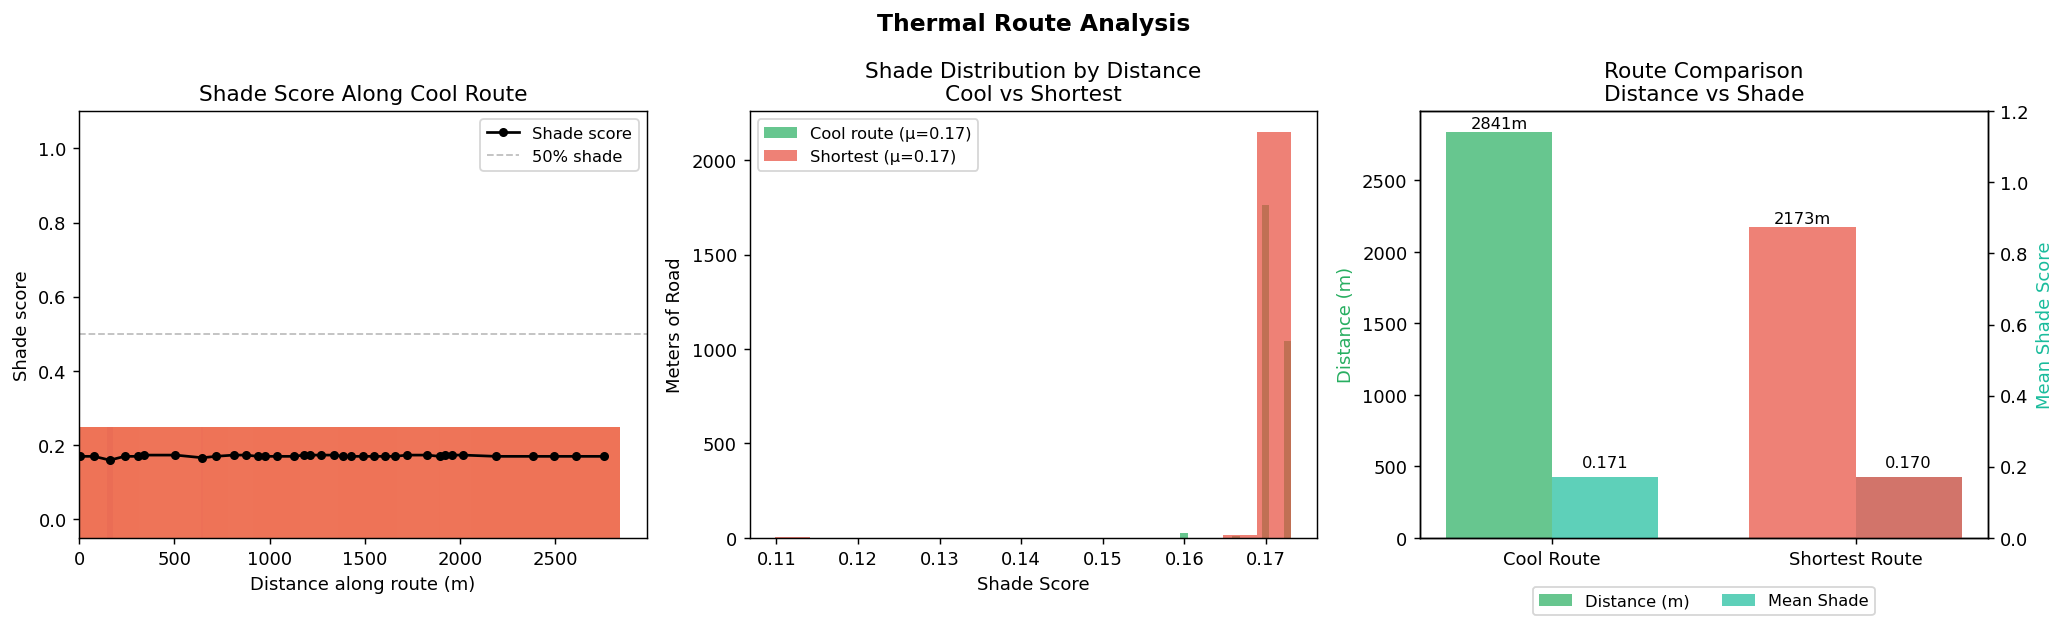

✅ Analysis plots saved to ../artifacts//route_analysis.png


In [32]:
# ─────────────────────────────────────────────────────────────────────
# CELL 14 ▸ ROUTE ANALYSIS PLOTS (HACKATHON EDITION)
# ─────────────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Thermal Route Analysis', fontsize=13, fontweight='bold')

segs = result.cool_route_segments

# ── Plot 1: Shade score along route ──
ax = axes[0]
cumulative_dist = [0]
for s in segs:
    cumulative_dist.append(cumulative_dist[-1] + s.length_m)
shade_vals = [s.shade_score for s in segs]

# Color-fill between min and max shade
for i, s in enumerate(segs):
    color = _shade_to_color(s.shade_score)
    ax.barh(0, s.length_m, left=cumulative_dist[i], height=0.5,
             color=color, alpha=0.85)
ax.plot([cumulative_dist[i] + segs[i].length_m/2 for i in range(len(segs))],
         [s.shade_score for s in segs], 'ko-', ms=4, lw=1.5, label='Shade score')
ax.axhline(0.5, color='gray', linestyle='--', lw=1, alpha=0.5, label='50% shade')
ax.set_xlabel('Distance along route (m)')
ax.set_ylabel('Shade score')
ax.set_title('Shade Score Along Cool Route')
ax.set_ylim(-0.05, 1.1)
ax.legend(fontsize=9)

# ── Plot 2: Cool vs Short route shade distribution ──
ax = axes[1]
# Get the short segments using the router
short_segs = router._get_route_segments(result.short_route_nodes, is_cool_route=False)

cool_shades  = [s.shade_score for s in result.cool_route_segments]
short_shades = [s.shade_score for s in short_segs]

# Use weighted lengths for histogram so it visually matches the total route length
cool_weights = [s.length_m for s in result.cool_route_segments]
short_weights = [s.length_m for s in short_segs]

ax.hist(cool_shades, bins=15, weights=cool_weights, alpha=0.7, color='#27AE60', 
        label=f'Cool route (μ={result.cool_mean_shade:.2f})')
ax.hist(short_shades, bins=15, weights=short_weights, alpha=0.7, color='#E74C3C', 
        label=f'Shortest (μ={result.short_mean_shade:.2f})')
ax.set_xlabel('Shade Score')
ax.set_ylabel('Meters of Road')
ax.set_title('Shade Distribution by Distance\nCool vs Shortest')
ax.legend(fontsize=9)

# ── Plot 3: Thermal cost breakdown ──
ax = axes[2]
route_labels = ['Cool Route', 'Shortest Route']
lengths      = [result.cool_total_length_m, result.short_total_length_m]
mean_shades  = [result.cool_mean_shade, result.short_mean_shade]
x = np.arange(len(route_labels))
width = 0.35

bars1 = ax.bar(x - width/2, lengths, width, label='Distance (m)',
                color=['#27AE60', '#E74C3C'], alpha=0.7)
ax2 = ax.twinx()
bars2 = ax2.bar(x + width/2, mean_shades, width, label='Mean Shade',
                 color=['#1ABC9C', '#C0392B'], alpha=0.7)

ax.set_xticks(x)
ax.set_xticklabels(route_labels)
ax.set_ylabel('Distance (m)', color='#27AE60')
ax2.set_ylabel('Mean Shade Score', color='#1ABC9C')
ax2.set_ylim(0, 1.2)
ax.set_title('Route Comparison\nDistance vs Shade')

# Annotations
for bar, val in zip(bars1, lengths):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{val:.0f}m', ha='center', va='bottom', fontsize=9)
for bar, val in zip(bars2, mean_shades):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
              f'{val:.3f}', ha='center', va='bottom', fontsize=9)

# Fix legend positioning
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines + lines2, labels + labels2, loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=2, fontsize=9)

plt.tight_layout()

import os
os.makedirs(CONFIG['output_dir'], exist_ok=True)
plt.savefig(f"{CONFIG['output_dir']}/route_analysis.png", dpi=130, bbox_inches='tight')
plt.show()
print(f'✅ Analysis plots saved to {CONFIG["output_dir"]}/route_analysis.png')

In [29]:
# ─────────────────────────────────────────────────────────────────────
# CELL 15 ▸ EXPORT GeoJSON FILES
#           For backend team to serve via API
# ─────────────────────────────────────────────────────────────────────

OUT = Path(CONFIG['output_dir'])

# 1. Cool route GeoJSON
cool_path = OUT / 'cool_route.geojson'
with open(cool_path, 'w') as f:
    json.dump(route.geojson_cool_route, f, indent=2)
print(f'✅ Cool route GeoJSON    : {cool_path}')

# 2. Shortest route GeoJSON (comparison)
short_path = OUT / 'shortest_route.geojson'
with open(short_path, 'w') as f:
    json.dump(route.geojson_short_route, f, indent=2)
print(f'✅ Shortest route GeoJSON: {short_path}')

# 3. Shelters GeoJSON
shelter_path = OUT / 'shelters.geojson'
with open(shelter_path, 'w') as f:
    json.dump(route.geojson_shelters, f, indent=2)
print(f'✅ Shelters GeoJSON       : {shelter_path}')

# 4. Route summary JSON (for API response)
summary = {
    'origin'               : {'lat': route.origin_coords[0], 'lon': route.origin_coords[1]},
    'destination'          : {'lat': route.destination_coords[0], 'lon': route.destination_coords[1]},
    'cool_route': {
        'total_length_m'       : route.cool_total_length_m,
        'mean_shade_score'     : route.cool_mean_shade,
        'heat_exposure_pct'    : route.cool_heat_exposure_pct,
        'n_segments'           : len(route.cool_route_segments),
        'shelters_count'       : len(route.shelters_on_route),
    },
    'shortest_route': {
        'total_length_m'       : route.short_total_length_m,
        'mean_shade_score'     : route.short_mean_shade,
    },
    'comparison': {
        'shade_improvement_pct': route.shade_improvement_pct,
        'extra_distance_m'     : route.extra_distance_m,
        'extra_distance_pct'   : route.extra_distance_pct,
    },
    'conditions': {
        'solar_elevation_deg'  : route.solar_elevation,
        'computed_at'          : route.computed_at,
    },
    'shelters': route.shelters_on_route,
}
summary_path = OUT / 'route_summary.json'
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)
print(f'✅ Route summary JSON    : {summary_path}')

print(f'\n📦 All GeoJSON files saved to: {OUT.resolve()}')
print('\n🗺️  Frontend team instructions:')
print('   1. Load cool_route.geojson into Leaflet/MapboxGL')
print('   2. Style each feature by its "shade_score" property')
print('      → green (score>0.75), yellow (0.5-0.75), red (<0.5)')
print('   3. Load shelters.geojson as point markers')
print('   4. Load shortest_route.geojson as a blue dashed overlay')
print('   5. Use route_summary.json for the info panel')

✅ Cool route GeoJSON    : ..\artifacts\cool_route.geojson
✅ Shortest route GeoJSON: ..\artifacts\shortest_route.geojson
✅ Shelters GeoJSON       : ..\artifacts\shelters.geojson
✅ Route summary JSON    : ..\artifacts\route_summary.json

📦 All GeoJSON files saved to: D:\heatsafe-navigator\routing\artifacts

🗺️  Frontend team instructions:
   1. Load cool_route.geojson into Leaflet/MapboxGL
   2. Style each feature by its "shade_score" property
      → green (score>0.75), yellow (0.5-0.75), red (<0.5)
   3. Load shelters.geojson as point markers
   4. Load shortest_route.geojson as a blue dashed overlay
   5. Use route_summary.json for the info panel


In [30]:
# ─────────────────────────────────────────────────────────────────────
# CELL 16 ▸ FASTAPI ROUTING ENDPOINT
#           Write routing/api/app.py for backend team
# ─────────────────────────────────────────────────────────────────────

api_code = '''
"""
HeatSafe Navigator — Routing API
FastAPI endpoint wrapping the ThermalRouteOptimizer.

Run:
    uvicorn app:app --reload --port 8001

NOTE: The graph G is loaded ONCE on startup and cached.
      Do NOT re-download OSM on every request — that would be too slow.
      The graph is pre-scored with shade model on startup.

Endpoints:
    GET  /health              → API status
    POST /route               → Find thermal route
    POST /route/batch         → Multiple routes
    GET  /docs                → Swagger UI
"""

import os, json, math, time, logging
from pathlib import Path
from datetime import datetime
from typing import Optional, List
from contextlib import asynccontextmanager

import numpy as np
import joblib
import requests   # for Nominatim geocoding
import osmnx as ox
import networkx as nx
import geopandas as gpd
from shapely.geometry import Point, mapping, LineString
import pvlib
from pvlib import location as pvloc
import pandas as pd

from fastapi import FastAPI, HTTPException
from fastapi.middleware.cors import CORSMiddleware
from pydantic import BaseModel, Field

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger("heatsafe.routing.api")

# ─── Config ───────────────────────────────────────────────────────────
BASE_DIR     = Path(__file__).parent.parent
ARTIFACT_DIR = BASE_DIR / "artifacts"
SHADE_DIR    = BASE_DIR.parent / "shade_model" / "artifacts"

CITY     = os.getenv("HEATSAFE_CITY",  "Dehradun, Uttarakhand, India")
LAT      = float(os.getenv("HEATSAFE_LAT",  "30.3165"))
LON      = float(os.getenv("HEATSAFE_LON",  "78.0322"))
TIMEZONE = os.getenv("HEATSAFE_TZ",   "Asia/Kolkata")
CRS      = "EPSG:32644"

W_DIST = 1.0
W_HEAT = 20.0
W_TIME = 5.0

# ─── App state (loaded once on startup) ───────────────────────────────
APP_STATE = {}


def load_shade_model():
    model    = joblib.load(SHADE_DIR / "shade_model.joblib")
    scaler   = joblib.load(SHADE_DIR / "scaler.joblib")
    encoders = joblib.load(SHADE_DIR / "label_encoders.joblib")
    with open(SHADE_DIR / "model_metadata.json") as f:
        meta = json.load(f)
    return {"model": model, "scaler": scaler, "encoders": encoders,
            "features": meta["features"], "highway_proxy": meta["highway_width_proxy"],
            "surface_factor": meta["surface_shade_factor"],
            "highway_classes": meta["highway_classes"],
            "surface_classes": meta["surface_classes"]}


def get_solar(lat, lon, hour=None):
    site = pvloc.Location(lat, lon, tz=TIMEZONE, altitude=700)
    if hour is None:
        hour = datetime.now().hour
    dt = pd.Timestamp(f"{datetime.now().strftime('%Y-%m-%d')} {hour:02d}:00:00", tz=TIMEZONE)
    sp = site.get_solarposition(pd.DatetimeIndex([dt]))
    elev = float(sp["elevation"].iloc[0])
    return {"elevation_deg": elev, "azimuth_deg": float(sp["azimuth"].iloc[0]),
            "heat_penalty": max(0.0, math.sin(math.radians(max(elev, 0)))) ** 0.5,
            "hour": hour}


def score_edge(data, geom, art, solar):
    """Score one edge — same logic as notebook EdgeShadeScorer."""
    def safe_first(v): return v[0] if isinstance(v, list) else v
    hw   = safe_first(data.get("highway", "unclassified"))
    sf   = safe_first(data.get("surface",  "asphalt"))
    length = float(data.get("length", 50))
    hw   = hw if hw in art["highway_proxy"] else "unclassified"
    sf   = sf if sf in art["surface_factor"] else "asphalt"
    w    = art["highway_proxy"].get(hw, 5.0)
    sfac = art["surface_factor"].get(sf, 0.1)
    le_hw = art["encoders"]["highway"]
    le_sf = art["encoders"]["surface"]
    hw_safe = hw if hw in art["highway_classes"] else art["highway_classes"][0]
    sf_safe = sf if sf in art["surface_classes"] else art["surface_classes"][0]
    hw_enc = int(le_hw.transform([hw_safe])[0])
    sf_enc = int(le_sf.transform([sf_safe])[0])
    elev = solar["elevation_deg"]
    az   = solar["azimuth_deg"]
    orient = 90.0
    if geom and len(list(geom.coords)) >= 2:
        coords = list(geom.coords)
        dx, dy = coords[-1][0]-coords[0][0], coords[-1][1]-coords[0][1]
        orient = math.degrees(math.atan2(dx, dy)) % 180
    shadow = 0.0
    if elev > 0:
        sl = 6.0 / math.tan(math.radians(elev))
        of = abs(math.sin(math.radians(az) - math.radians(orient)))
        shadow = min(sl * of, 50) / (w/2 + min(sl * of, 50) + 1e-6)
    fmap = {
        "road_width": w, "road_orientation_deg": orient, "is_oneway": int(bool(data.get("oneway", False))),
        "highway_enc": hw_enc, "surface_enc": sf_enc, "surface_factor": sfac,
        "building_height_mean": 6.0, "shadow_mean": shadow, "shadow_peak": shadow,
        "shadow_min": shadow*0.5, "shadow_noon": shadow,
        "sun_elevation_noon": max(elev, 0),
        "length_m_log": math.log1p(length), "tree_count_log": 0.0,
        "tree_density_log": 0.0, "building_count_log": 0.0,
    }
    row = np.array([fmap.get(f, 0.0) for f in art["features"]]).reshape(1, -1)
    row_s = art["scaler"].transform(row)
    return float(min(max(art["model"].predict(row_s)[0], 0.0), 1.0))


def thermal_cost(length, shade, solar_pen):
    base_cost = length * W_DIST
    heat_exposure = 1.0 - shade
    time_penalty  = heat_exposure * solar_pen
    penalty_multiplier = (W_HEAT * heat_exposure) + (W_TIME * time_penalty)
    total_cost = base_cost + (length * penalty_multiplier)
    return round(total_cost, 6)


@asynccontextmanager
async def lifespan(app: FastAPI):
    """Load heavy resources once on startup."""
    logger.info("⏳ Loading shade model...")
    art = load_shade_model()
    APP_STATE["artifacts"] = art

    logger.info(f"⏳ Downloading street network: {CITY}")
    G_raw = ox.graph_from_place(CITY, network_type="walk", simplify=True)
    G = ox.project_graph(G_raw, to_crs=CRS)

    logger.info("⏳ Pre-scoring all edges...")
    solar = get_solar(LAT, LON)
    for u, v, k, data in G.edges(data=True, keys=True):
        geom = data.get("geometry", None)
        shade = score_edge(data, geom, art, solar)
        tc    = thermal_cost(float(data.get("length", 50)), shade, solar["heat_penalty"])
        G[u][v][k]["shade_score"]  = shade
        G[u][v][k]["thermal_cost"] = tc

    APP_STATE["G"]     = G
    APP_STATE["solar"] = solar
    logger.info(f"✅ Ready — {G.number_of_edges():,} edges scored")
    yield
    APP_STATE.clear()


app = FastAPI(
    title="HeatSafe Navigator — Routing API",
    description="Thermal route optimization for outdoor worker safety",
    version="1.0.0",
    lifespan=lifespan,
)
app.add_middleware(CORSMiddleware, allow_origins=["*"], allow_methods=["*"], allow_headers=["*"])


# ─── Schemas ──────────────────────────────────────────────────────────
class RouteRequest(BaseModel):
    # ── Option A: Place names (recommended — no coordinates needed) ──
    origin_name:     Optional[str] = Field(None, example="clock tower",
                       description="Origin place name (geocoded automatically via OSM Nominatim)")
    dest_name:       Optional[str] = Field(None, example="parade ground",
                       description="Destination place name (geocoded automatically)")

    # ── Option B: Raw coordinates (fallback) ─────────────────────────
    origin_lat:      Optional[float] = Field(None, example=30.3248)
    origin_lon:      Optional[float] = Field(None, example=78.0435)
    dest_lat:        Optional[float] = Field(None, example=30.3159)
    dest_lon:        Optional[float] = Field(None, example=78.0324)

    hour:            Optional[int] = Field(None, ge=0, le=23,
                       description="Hour 0-23. Defaults to current IST hour (real-time solar angle).")
    include_geojson: bool = Field(True, description="Include GeoJSON in response (set False for summary only)")


class BatchRouteRequest(BaseModel):
    routes: List[RouteRequest]


# ─── Endpoints ────────────────────────────────────────────────────────
@app.get("/health")
def health():
    G = APP_STATE.get("G")
    return {
        "status": "ok",
        "city": CITY,
        "graph_edges": G.number_of_edges() if G else 0,
        "graph_nodes": G.number_of_nodes() if G else 0,
        "solar_elevation": APP_STATE.get("solar", {}).get("elevation_deg"),
    }


def _geocode(name: str) -> tuple:
    """OSM Nominatim geocoder — free, no API key. Returns (lat, lon)."""
    import requests as _req
    url = "https://nominatim.openstreetmap.org/search"
    params = {"q": f"{name}, Dehradun, Uttarakhand, India",
              "format": "json", "limit": 1, "countrycodes": "in",
              "viewbox": "77.85,30.15,78.25,30.55", "bounded": 1}
    try:
        r = _req.get(url, params=params,
                     headers={"User-Agent": "HeatSafeNavigator/1.0"}, timeout=8)
        d = r.json()
        if d:
            return float(d[0]["lat"]), float(d[0]["lon"])
    except Exception as e:
        logger.warning(f"Nominatim error for '{name}': {e}")
    raise HTTPException(400, f"Cannot geocode '{name}'. Try a more specific name.")


@app.post("/route")
def find_route(req: RouteRequest):
    G   = APP_STATE.get("G")
    art = APP_STATE.get("artifacts")
    if G is None:
        raise HTTPException(503, "Graph not loaded yet")

    try:
        # ── Solar: always real-time IST hour, not hardcoded ───────────
        solar = get_solar(LAT, LON, req.hour)   # req.hour=None → uses datetime.now().hour

        # ── Resolve origin: place name OR raw coordinates ─────────────
        if req.origin_name:
            o_lat, o_lon = _geocode(req.origin_name)
        elif req.origin_lat is not None and req.origin_lon is not None:
            o_lat, o_lon = req.origin_lat, req.origin_lon
        else:
            raise HTTPException(400, "Provide origin_name or origin_lat+origin_lon")

        # ── Resolve destination ────────────────────────────────────────
        if req.dest_name:
            d_lat, d_lon = _geocode(req.dest_name)
        elif req.dest_lat is not None and req.dest_lon is not None:
            d_lat, d_lon = req.dest_lat, req.dest_lon
        else:
            raise HTTPException(400, "Provide dest_name or dest_lat+dest_lon")

        orig_gdf = gpd.GeoDataFrame(geometry=[Point(o_lon, o_lat)], crs="EPSG:4326").to_crs(CRS)
        dest_gdf = gpd.GeoDataFrame(geometry=[Point(d_lon, d_lat)], crs="EPSG:4326").to_crs(CRS)
        orig = ox.distance.nearest_nodes(G, X=orig_gdf.geometry.iloc[0].x, Y=orig_gdf.geometry.iloc[0].y)
        dest = ox.distance.nearest_nodes(G, X=dest_gdf.geometry.iloc[0].x, Y=dest_gdf.geometry.iloc[0].y)

        cool_nodes  = nx.shortest_path(G, orig, dest, weight="thermal_cost", method="dijkstra")
        short_nodes = nx.shortest_path(G, orig, dest, weight="length",       method="dijkstra")

        def summarize_nodes(nodes):
            total_len = 0
            weighted_shades = 0
            feats = []
            for i in range(len(nodes)-1):
                u, v = nodes[i], nodes[i+1]
                bk = min(G[u][v], key=lambda k: G[u][v][k].get("thermal_cost", 999))
                d  = G[u][v][bk]
                seg_len = float(d.get("length", 0))
                shade = float(d.get("shade_score", 0.15))
                
                total_len += seg_len
                weighted_shades += (shade * seg_len)
                
                if req.include_geojson:
                    geom = d.get("geometry", None)
                    if geom is None:
                        n1, n2 = G.nodes[u], G.nodes[v]
                        geom = LineString([(n1["x"],n1["y"]),(n2["x"],n2["y"])])
                    g_wgs = gpd.GeoDataFrame(geometry=[geom], crs=CRS).to_crs("EPSG:4326").geometry.iloc[0]
                    from matplotlib import colors as mcolors
                    import matplotlib.pyplot as plt
                    feats.append({"type": "Feature", "geometry": mapping(g_wgs),
                                   "properties": {"shade_score": shade,
                                                  "color": mcolors.to_hex(plt.cm.RdYlGn(shade)),
                                                  "length_m": seg_len}})
            
            mean_shade = weighted_shades / max(total_len, 1)
            return total_len, mean_shade, feats

        cool_len,  cool_shade,  cool_feats  = summarize_nodes(cool_nodes)
        short_len, short_shade, short_feats = summarize_nodes(short_nodes)

        resp = {
            "cool_route": {
                "total_length_m":   round(cool_len, 1),
                "mean_shade_score": round(cool_shade, 4),
                "heat_exposure_pct": round((1-cool_shade)*100, 1),
                "n_segments":       len(cool_nodes)-1,
            },
            "shortest_route": {
                "total_length_m":   round(short_len, 1),
                "mean_shade_score": round(short_shade, 4),
            },
            "comparison": {
                "shade_improvement_pct": round(((cool_shade-short_shade)/max(short_shade,0.01))*100, 1),
                "extra_distance_m":      round(cool_len - short_len, 1),
                "extra_distance_pct":    round(((cool_len-short_len)/max(short_len,1))*100, 1),
            },
            "solar_elevation_deg": solar["elevation_deg"],
            "computed_at":         datetime.now().isoformat(),
        }
        if req.include_geojson:
            resp["geojson_cool_route"]  = {"type": "FeatureCollection", "features": cool_feats}
            resp["geojson_short_route"] = {"type": "FeatureCollection", "features": short_feats}
        return resp

    except nx.NetworkXNoPath:
        raise HTTPException(400, "No path found. Try different coordinates within the city.")
    except Exception as e:
        logger.error(f"Route error: {e}")
        raise HTTPException(500, str(e))


@app.post("/route/batch")
def batch_routes(req: BatchRouteRequest):
    if len(req.routes) > 20:
        raise HTTPException(400, "Max 20 routes per batch")
    return [find_route(r) for r in req.routes]


@app.get("/docs-summary")
def docs_summary():
    return {
        "endpoints": [
            {"method": "GET",  "path": "/health",        "description": "API status + graph stats"},
            {"method": "POST", "path": "/route",         "description": "Find thermal route between two points"},
            {"method": "POST", "path": "/route/batch",   "description": "Find up to 20 routes in parallel"},
            {"method": "GET",  "path": "/docs",          "description": "Swagger UI"},
        ],
        "example_request": {
            "origin_lat": 30.3248, "origin_lon": 78.0435,
            "dest_lat": 30.3159,   "dest_lon": 78.0324,
            "hour": 13, "include_geojson": True
        }
    }
'''

api_path = Path('../api/app.py')
api_path.parent.mkdir(parents=True, exist_ok=True)
api_path.write_text(api_code.strip(), encoding='utf-8')
print(f'✅ FastAPI routing app written: {api_path.resolve()}')
print()
print('To run the routing API:')
print('  cd heatsafe-navigator/routing/api')
print('  uvicorn app:app --reload --port 8001')
print()
print('Frontend team — call this endpoint:')
print('  POST http://localhost:8001/route')
print('  Body: {"origin_lat": ..., "origin_lon": ..., "dest_lat": ..., "dest_lon": ...}')
print('  Response: GeoJSON for cool route + shortest route + shelters')

✅ FastAPI routing app written: D:\heatsafe-navigator\routing\api\app.py

To run the routing API:
  cd heatsafe-navigator/routing/api
  uvicorn app:app --reload --port 8001

Frontend team — call this endpoint:
  POST http://localhost:8001/route
  Body: {"origin_lat": ..., "origin_lon": ..., "dest_lat": ..., "dest_lon": ...}
  Response: GeoJSON for cool route + shortest route + shelters


In [ ]:
# ─────────────────────────────────────────────────────────────────────
# CELL: STANDALONE BAKE GRAPH (8 AM to 6 PM) -> Saves to ../artifacts
# ─────────────────────────────────────────────────────────────────────
import os, json, math, pickle, logging
from pathlib import Path
from datetime import datetime
from tqdm.notebook import tqdm

import numpy as np
import pandas as pd
import joblib
import osmnx as ox
import networkx as nx
import pvlib
from pvlib import location as pvloc

# ─── Config ──────────────────────────────────────────────────────────
CITY = "Dehradun, Uttarakhand, India"
LAT = 30.3165
LON = 78.0322
TIMEZONE = "Asia/Kolkata"
CRS = "EPSG:32644"

# Set up paths relative to the notebook folder (routing/notebooks/)
NOTEBOOK_DIR = Path.cwd()
ROUTING_DIR = NOTEBOOK_DIR.parent
ARTIFACT_DIR = ROUTING_DIR / "artifacts"
ARTIFACT_DIR.mkdir(exist_ok=True)
OUTPUT_PATH = ARTIFACT_DIR / "baked_graph.pkl"

# Path to your ML model
SHADE_DIR = ROUTING_DIR.parent / "shade_model" / "artifacts"

logging.getLogger().setLevel(logging.INFO)

# ─── Functions ───────────────────────────────────────────────────────
def load_shade_model():
    model    = joblib.load(SHADE_DIR / "shade_model.joblib")
    scaler   = joblib.load(SHADE_DIR / "scaler.joblib")
    encoders = joblib.load(SHADE_DIR / "label_encoders.joblib")
    with open(SHADE_DIR / "model_metadata.json") as f:
        meta = json.load(f)
    return {"model": model, "scaler": scaler, "encoders": encoders,
            "features": meta["features"], "highway_proxy": meta["highway_width_proxy"],
            "surface_factor": meta["surface_shade_factor"],
            "highway_classes": meta["highway_classes"],
            "surface_classes": meta["surface_classes"]}

def get_solar(lat, lon, hour):
    site = pvloc.Location(lat, lon, tz=TIMEZONE, altitude=700)
    dt = pd.Timestamp(f"{datetime.now().strftime('%Y-%m-%d')} {hour:02d}:00:00", tz=TIMEZONE)
    sp = site.get_solarposition(pd.DatetimeIndex([dt]))
    elev = float(sp["elevation"].iloc[0])
    return {"elevation_deg": elev, "azimuth_deg": float(sp["azimuth"].iloc[0]),
            "heat_penalty": max(0.0, math.sin(math.radians(max(elev, 0)))) ** 0.5,
            "hour": hour}

def score_edge(data, geom, art, solar):
    def safe_first(v): return v[0] if isinstance(v, list) else v
    hw = safe_first(data.get("highway", "unclassified"))
    sf = safe_first(data.get("surface", "asphalt"))
    length = float(data.get("length", 50))
    hw = hw if hw in art["highway_proxy"] else "unclassified"
    sf = sf if sf in art["surface_factor"] else "asphalt"
    w = art["highway_proxy"].get(hw, 5.0)
    sfac = art["surface_factor"].get(sf, 0.1)
    
    le_hw = art["encoders"]["highway"]
    le_sf = art["encoders"]["surface"]
    hw_safe = hw if hw in art["highway_classes"] else art["highway_classes"][0]
    sf_safe = sf if sf in art["surface_classes"] else art["surface_classes"][0]
    hw_enc = int(le_hw.transform([hw_safe])[0])
    sf_enc = int(le_sf.transform([sf_safe])[0])
    
    elev = solar["elevation_deg"]
    az = solar["azimuth_deg"]
    orient = 90.0
    if geom and len(list(geom.coords)) >= 2:
        coords = list(geom.coords)
        dx, dy = coords[-1][0]-coords[0][0], coords[-1][1]-coords[0][1]
        orient = math.degrees(math.atan2(dx, dy)) % 180
        
    shadow = 0.0
    if elev > 0:
        sl = 6.0 / math.tan(math.radians(elev))
        of = abs(math.sin(math.radians(az) - math.radians(orient)))
        shadow = min(sl * of, 50) / (w/2 + min(sl * of, 50) + 1e-6)
        
    fmap = {
        "road_width": w, "road_orientation_deg": orient, "is_oneway": int(bool(data.get("oneway", False))),
        "highway_enc": hw_enc, "surface_enc": sf_enc, "surface_factor": sfac,
        "building_height_mean": 6.0, "shadow_mean": shadow, "shadow_peak": shadow,
        "shadow_min": shadow*0.5, "shadow_noon": shadow,
        "sun_elevation_noon": max(elev, 0),
        "length_m_log": math.log1p(length), "tree_count_log": 0.0,
        "tree_density_log": 0.0, "building_count_log": 0.0,
    }
    row = np.array([fmap.get(f, 0.0) for f in art["features"]]).reshape(1, -1)
    row_s = art["scaler"].transform(row)
    return float(min(max(art["model"].predict(row_s)[0], 0.0), 1.0))

# ─── Execution ───────────────────────────────────────────────────────
print(f"1. Downloading Graph for {CITY}...")
G_raw = ox.graph_from_place(CITY, network_type="walk", simplify=True)
G_bake = ox.project_graph(G_raw, to_crs=CRS)

print("2. Loading ML Artifacts...")
art = load_shade_model()

print("3. Pre-calculating Solar Profiles for 8 AM to 6 PM...")
solar_profiles = {h: get_solar(LAT, LON, h) for h in range(8, 19)}

print(f"4. Scoring {G_bake.number_of_edges()} edges... (Look at progress bar!)")
edges = list(G_bake.edges(data=True, keys=True))

for u, v, k, data in tqdm(edges, desc="Baking Shadows"):
    geom = data.get("geometry", None)
    shade_hourly = {}
    
    for h in range(8, 19):
        shade = score_edge(data, geom, art, solar_profiles[h])
        shade_hourly[h] = round(shade, 4)
        
    # NOTE: I am intentionally keeping geometry here so the frontend map draws roads perfectly.
    G_bake[u][v][k]["shade_hourly"] = shade_hourly
    G_bake[u][v][k]["length"] = float(data.get("length", 50))

print("5. Saving baked graph to artifacts folder...")
with open(OUTPUT_PATH, "wb") as f:
    pickle.dump(G_bake, f)
    
print(f"✅ DONE! File saved to: {OUTPUT_PATH.resolve()}")

1. Downloading Graph for Dehradun, Uttarakhand, India...
2. Loading ML Artifacts...
3. Pre-calculating Solar Profiles for 8 AM to 6 PM...
4. Scoring 136924 edges... (Look at progress bar!)


Baking Shadows:   0%|          | 0/136924 [00:00<?, ?it/s]

5. Saving baked graph to artifacts folder...
✅ DONE! File saved to: D:\heatsafe-navigator\routing\artifacts\baked_graph.pkl


: 

In [21]:
# ─────────────────────────────────────────────────────────────────────
# CELL 17 ▸ FINAL PROJECT STRUCTURE SUMMARY
# ─────────────────────────────────────────────────────────────────────

print("""
╔══════════════════════════════════════════════════════════════════╗
║         HeatSafe Navigator — Complete Project Structure          ║
╚══════════════════════════════════════════════════════════════════╝

heatsafe-navigator/
├── .env.example               ← Copy to .env, add your keys
├── .gitignore
├── pyproject.toml             ← uv package manager config
├── requirements.txt           ← pip fallback
│
├── shade_model/               ← MODULE 1: Shade ML model
│   ├── notebooks/
│   │   └── shade_model.ipynb  ← ✅ ALREADY DONE
│   └── artifacts/             ← shade_model.joblib, scaler.joblib,
│                                  label_encoders.joblib, model_metadata.json
│
├── llm_engine/                ← MODULE 2: LLM Occupation Profiler
│   ├── notebooks/
│   │   └── occupation_profiler_niosh_psi.ipynb  ← ✅ ALREADY DONE
│   ├── src/schemas.py         ← Pydantic schemas for API
│   ├── artifacts/             ← niosh_tables.json, sample_output.json
│   └── rag/                   ← MODULE 2b: RAG pipeline (next)
│       ├── documents/         ← ← PUT YOUR NIOSH PDFS HERE
│       ├── vector_store/      ← ChromaDB auto-creates this
│       └── notebooks/rag_pipeline.ipynb (coming next)
│
├── routing/                   ← MODULE 3: Thermal Router (THIS FILE)
│   ├── notebooks/
│   │   └── thermal_router.ipynb  ← ✅ THIS FILE
│   ├── src/__init__.py
│   ├── artifacts/             ← GeoJSON exports, HTML map
│   └── api/
│       └── app.py             ← FastAPI routing endpoint (port 8001)
│
└── api/                       ← MODULE 4: Unified API (combines all)
    └── routers/               ← (future: merge all 3 FastAPI apps here)

═══════════════════════════════════════════════════════════════════
WHERE TO RUN EACH FILE:

  shade_model.ipynb             → Run IN JUPYTER (builds the ML model)
  occupation_profiler.ipynb     → Run IN JUPYTER (builds LLM profiler)
  thermal_router.ipynb          → Run IN JUPYTER (builds routes + maps)

  llm_engine/api/app.py         → Run with uvicorn (port 8000) — worker input
  routing/api/app.py            → Run with uvicorn (port 8001) — route queries

  FRONTEND TEAM — consumes:
    POST :8000/predict          → Worker heat risk
    POST :8001/route            → Cool route GeoJSON

═══════════════════════════════════════════════════════════════════
FRONTEND MAP IMPLEMENTATION (for your team):

  Library options (all free):
    • Leaflet.js    — simplest, CDN, no token needed
    • MapboxGL JS   — better, free tier with token
    • Google Maps JS — familiar, free $200/mo credit

  Implementation steps:
    1. Call POST /route with origin + destination
    2. Response contains geojson_cool_route (FeatureCollection)
    3. Each Feature has property "color" (hex, pre-computed by API)
    4. Load GeoJSON → style each LineString by its "color" property
    5. Load shelters GeoJSON → add as point markers
    6. Show info panel from "comparison" object in response

  Leaflet code (4 lines):
    L.geoJSON(geojson_cool_route, {
      style: feature => ({
        color: feature.properties.color,
        weight: 6, opacity: 0.9
      })
    }).addTo(map);
""")

print('✅ NOTEBOOK COMPLETE')


╔══════════════════════════════════════════════════════════════════╗
║         HeatSafe Navigator — Complete Project Structure          ║
╚══════════════════════════════════════════════════════════════════╝

heatsafe-navigator/
├── .env.example               ← Copy to .env, add your keys
├── .gitignore
├── pyproject.toml             ← uv package manager config
├── requirements.txt           ← pip fallback
│
├── shade_model/               ← MODULE 1: Shade ML model
│   ├── notebooks/
│   │   └── shade_model.ipynb  ← ✅ ALREADY DONE
│   └── artifacts/             ← shade_model.joblib, scaler.joblib,
│                                  label_encoders.joblib, model_metadata.json
│
├── llm_engine/                ← MODULE 2: LLM Occupation Profiler
│   ├── notebooks/
│   │   └── occupation_profiler_niosh_psi.ipynb  ← ✅ ALREADY DONE
│   ├── src/schemas.py         ← Pydantic schemas for API
│   ├── artifacts/             ← niosh_tables.json, sample_output.json
│   └── rag/                   ← M